# 4. Gene Embedding Extraction

Extract **cell / gene embeddings** from the frozen-split masking checkpoint, **held-out test only**.

| Setting | Value |
|---|---|
| ckpt | `masking_split/...20260808_2325...epoch=49.ckpt` |
| split | `True` + frozen `--split_path` (test indices only) |
| context_mode | `True` (must match training) |
| GPUs | **1 GPU** (embedding dump is not DDP-safe) |
| outputs | sod2: `.../res/masking_split/embeddings_benchmark_test_paper_v1` |

Metrics-only test lives in notebook 03 §3.4. This notebook does **not** report MLM loss (`return_embeddings=True` -> `not_masked`).

Run this notebook top → bottom (params → build cmd → launch). Long extract: start Jupyter inside `screen` if you want to detach.


## 4.1. Parameters

Update GPU id if 0 is busy. Keep `SPLIT_PATH` aligned with notebook 02 / 03.


In [19]:
import os
from pathlib import Path

WORKSPACE = Path("/home/stuke1/perturbgen")
REPO = WORKSPACE / "Perturbgen"
TOKENIZED = WORKSPACE / "T_perturb" / "tokenized_data" / "LPS_all_tps_2k"
SOD2_ROOT = Path("/mnt/sod2-project/csb4/stuke1/perturbgen")

# Single GPU for embedding extract (val.py also forces n_devices=1)
os.environ["CUDA_VISIBLE_DEVICES"] = "7"
os.environ["WANDB_MODE"] = "offline"
os.environ["WANDB_DIR"] = str(SOD2_ROOT / "wandb")
os.environ["TMPDIR"] = str(SOD2_ROOT / "tmp")
os.environ["MPLBACKEND"] = "Agg"
os.environ["MPLCONFIGDIR"] = "/tmp/matplotlib"
os.environ["NUMBA_CACHE_DIR"] = "/tmp/numba_cache"
os.environ["HWLOC_COMPONENTS"] = "-gl"
os.environ["HWLOC_GL_LINUX_NVIDIA_DISABLE"] = "1"
os.environ.pop("DISPLAY", None)
os.environ.pop("WAYLAND_DISPLAY", None)

# New 50-epoch frozen-split ckpt (train/val/test from notebook 02 §2.6)
CKPT_MASKING_PATH = str(
    WORKSPACE
    / "T_perturb"
    / "res"
    / "masking_split"
    / "checkpoints"
    / "20260808_2325_cellgen_train_masking_lr_0.0001_wd_0.0001_batch_64_ptime_pos_sin_m_pow_tp_1-2-3_s_0-epoch=49.ckpt"
)
SPLIT_PATH = str(
    TOKENIZED
    / "splits"
    / "stratified_cell_type_harmonized_seed42_80_10_10.pkl"
)

# Test-only benchmark directory naming.
BENCHMARK_TAG = "paper_v1"
OUTPUT_DIR_PATH = (
    SOD2_ROOT / "T_perturb" / "res"
    / "masking_split" / f"embeddings_benchmark_test_{BENCHMARK_TAG}"
)
OUTPUT_DIR = str(OUTPUT_DIR_PATH)
EXPECTED_INFERENCE_H5AD = str(
    OUTPUT_DIR_PATH / f"benchmark_test_{BENCHMARK_TAG}_inference_embs.h5ad"
)
assert OUTPUT_DIR.startswith("/mnt/sod2-project/csb4"), (
    f"OUTPUT_DIR must be on sod2, got {OUTPUT_DIR}"
)

SRC_DATASET = str(TOKENIZED / "dataset_2000_hvg_src" / "normal.dataset")
TGT_DATASET_FOLDER = str(TOKENIZED / "dataset_2000_hvg_tgt")
SRC_ADATA = str(TOKENIZED / "h5ad_pairing_2000_hvg_src" / "normal.h5ad")
TGT_ADATA_FOLDER = str(TOKENIZED / "h5ad_pairing_2000_hvg_tgt")
MAPPING_DICT_PATH = str(TOKENIZED / "token_id_to_genename_2000_hvg.pkl")
TOKENID_TO_ROWID = str(TOKENIZED / "tokenid_to_rowid_2000_hvg.pkl")

ENCODER_PATH = str(
    REPO
    / "pretraining_cohort"
    / "20250709_1223_cellgen_train_masking_lr_5e-05_wd_1e-06_batch_64_ptime_pos_sin_m_pow_tp_1-2-3_s_42-epoch=00.ckpt"
)

BATCH_SIZE = 32
N_WORKERS = 0
PRED_TPS = ["1", "2", "3"]  # 1=90m, 2=6h, 3=10h
VAR_LIST = ["cell_pairing_index", "time_after_LPS", "cell_type_harmonized"]

ENCODER = "scmaskgit"
CONTEXT_MODE = "True"
MASK_SCHEDULER = "pow"
POS_ENCODING_MODE = "time_pos_sin"
D_MODEL = 768
D_FF = 32
NUM_LAYERS = 6

RETURN_EMBEDDINGS = "True"
RETURN_GENE_EMBS = "True"
GENE_EMBS_CONDITION = "time_after_LPS"
RETURN_ATTN = "False"
GENERATE = "False"

for p in (CKPT_MASKING_PATH, SPLIT_PATH, ENCODER_PATH, SRC_DATASET, SRC_ADATA, TOKENID_TO_ROWID):
    if not Path(p).exists():
        raise FileNotFoundError(p)

Path(OUTPUT_DIR).mkdir(parents=True, exist_ok=True)
ckpt_info = Path(OUTPUT_DIR) / "ckpt_info.txt"
ckpt_info.write_text(
    "\n".join([
        f"ckpt={CKPT_MASKING_PATH}",
        f"split_path={SPLIT_PATH}",
        "split=True (held-out test only)",
        "context_mode=True",
        "return_embeddings=True",
        "return_gene_embs=True",
        f"pred_tps={PRED_TPS}",
    ]) + "\n"
)
print("Wrote", ckpt_info)
Path(os.environ["WANDB_DIR"]).mkdir(parents=True, exist_ok=True)
Path(os.environ["TMPDIR"]).mkdir(parents=True, exist_ok=True)

print("CKPT:", CKPT_MASKING_PATH)
print("SPLIT_PATH:", SPLIT_PATH)
print("OUTPUT_DIR:", OUTPUT_DIR)
print("CUDA_VISIBLE_DEVICES:", os.environ["CUDA_VISIBLE_DEVICES"])
print("context_mode:", CONTEXT_MODE, "| split: True (test only)")


Wrote /mnt/sod2-project/csb4/stuke1/perturbgen/T_perturb/res/masking_split/embeddings_benchmark_test_paper_v1/ckpt_info.txt
CKPT: /home/stuke1/perturbgen/T_perturb/res/masking_split/checkpoints/20260808_2325_cellgen_train_masking_lr_0.0001_wd_0.0001_batch_64_ptime_pos_sin_m_pow_tp_1-2-3_s_0-epoch=49.ckpt
SPLIT_PATH: /home/stuke1/perturbgen/T_perturb/tokenized_data/LPS_all_tps_2k/splits/stratified_cell_type_harmonized_seed42_80_10_10.pkl
OUTPUT_DIR: /mnt/sod2-project/csb4/stuke1/perturbgen/T_perturb/res/masking_split/embeddings_benchmark_test_paper_v1
CUDA_VISIBLE_DEVICES: 7
context_mode: True | split: True (test only)


## 4.2. Build the command

`extract-embedding` → `perturbgen.val` → `trainer.test` on **test_indices** from `SPLIT_PATH`.


In [ ]:
cmd = [
    "python", "-m", "perturbgen", "extract-embedding",
    "--test_mode", "masking",
    "--split", "True",
    "--split_path", SPLIT_PATH,
    "--context_mode", CONTEXT_MODE,
    "--return_embeddings", RETURN_EMBEDDINGS,
    "--return_gene_embs", RETURN_GENE_EMBS,
    "--gene_embs_condition", GENE_EMBS_CONDITION,
    "--return_attn", RETURN_ATTN,
    "--generate", GENERATE,
    "--ckpt_masking_path", CKPT_MASKING_PATH,
    "--output_dir", OUTPUT_DIR,
    "--src_dataset", SRC_DATASET,
    "--tgt_dataset_folder", TGT_DATASET_FOLDER,
    "--src_adata", SRC_ADATA,
    "--tgt_adata_folder", TGT_ADATA_FOLDER,
    "--mapping_dict_path", MAPPING_DICT_PATH,
    "--tokenid_to_rowid", TOKENID_TO_ROWID,
    "--batch_size", str(BATCH_SIZE),
    "--n_workers", str(N_WORKERS),
    "--pred_tps", *PRED_TPS,
    "--var_list", *VAR_LIST,
    "--encoder", ENCODER,
    "--encoder_path", ENCODER_PATH,
    "--mask_scheduler", MASK_SCHEDULER,
    "--pos_encoding_mode", POS_ENCODING_MODE,
    "--d_model", str(D_MODEL),
    "--d_ff", str(D_FF),
    "--num_layers", str(NUM_LAYERS),
    "--wandb_mode", "offline",
]

print(" ".join(cmd))


## 4.3. Launch

Expect log lines: `Loaded frozen split from ...` and `Number of samples in test set: 14811`.


In [ ]:
import subprocess

assert "sod2-project" in OUTPUT_DIR, (
    f"Refusing to run: OUTPUT_DIR is not on sod2: {OUTPUT_DIR}"
)
assert Path(CKPT_MASKING_PATH).is_file()
assert Path(SPLIT_PATH).is_file()

env = os.environ.copy()
env["CUDA_VISIBLE_DEVICES"] = os.environ["CUDA_VISIBLE_DEVICES"]
env["WANDB_MODE"] = "offline"
env["PYTHONUNBUFFERED"] = "1"

print("Launching extract-embedding on GPU", env["CUDA_VISIBLE_DEVICES"])
print("OUTPUT_DIR:", OUTPUT_DIR)
print(" ".join(cmd))

subprocess.run(cmd, check=True, cwd=str(WORKSPACE), env=env)
print("Done. Outputs under:", OUTPUT_DIR)


In [20]:
import os
os.environ["NUMBA_CACHE_DIR"] = "/tmp/numba_cache"
os.environ["MPLCONFIGDIR"] = "/tmp/matplotlib"

import anndata as ad
import scanpy as sc
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import silhouette_score

In [21]:
# Load benchmark-named inference artifact first; fallback to latest only if needed.
expected = Path(EXPECTED_INFERENCE_H5AD)
if expected.exists():
    h5ad_path = str(expected)
else:
    candidates = sorted(Path(OUTPUT_DIR).glob("*inference_embs*.h5ad"))
    if not candidates:
        raise FileNotFoundError(f"No inference h5ad found under {OUTPUT_DIR}")
    h5ad_path = str(candidates[-1])
    print("Warning: expected benchmark-named file not found, using latest:", h5ad_path)

adata = ad.read_h5ad(h5ad_path)

print("Loaded:", h5ad_path)
print("adata shape:", adata.shape)
print("obs columns:", list(adata.obs.columns))
print("obsm keys:", list(adata.obsm.keys()))

required_obs = ["cell_type_harmonized", "time_after_LPS", "batch", "cell_idx"]
missing_obs = [k for k in required_obs if k not in adata.obs.columns]
if missing_obs:
    raise KeyError(f"Missing required obs columns: {missing_obs}")
if "cls_embeddings" not in adata.obsm:
    raise KeyError("Expected 'cls_embeddings' in adata.obsm")

Loaded: /mnt/sod2-project/csb4/stuke1/perturbgen/T_perturb/res/masking_split/embeddings_benchmark_test_paper_v1/benchmark_test_paper_v1_inference_embs.h5ad
adata shape: (26856, 1856)
obs columns: ['cell_pairing_index', 'time_after_LPS', 'cell_type_harmonized', 'batch', 'cell_idx']
obsm keys: ['cls_embeddings']


## 4.4. Why `adata.n_obs` can differ from split test size

This section computes, from first principles, why the exported embedding table can have more rows than `len(test_indices)`:

- split test size from frozen split
- effective size after `drop_last=True`
- per-timepoint unique `cell_pairing_index` counts
- union across timepoints

`adata.n_obs` should be close to that union (after export-side dedup logic).

In [22]:
import pickle
from datasets import load_from_disk

with open(SPLIT_PATH, "rb") as f:
    split_payload = pickle.load(f)

test_idx = np.asarray(split_payload["test_indices"], dtype=np.int64)
raw_test_n = int(test_idx.size)

effective_test_n = (raw_test_n // BATCH_SIZE) * BATCH_SIZE  # test loader uses drop_last=True
trimmed_idx = test_idx[:effective_test_n]

print("split test size:", raw_test_n)
print("effective after drop_last:", effective_test_n)

per_tp_rows = {}
per_tp_unique = {}
union_ids = set()

for tp in PRED_TPS:
    ds_path = Path(TGT_DATASET_FOLDER) / f"{tp}_" if False else None

# Build target dataset names exactly like tokenization outputs: 1_90m_LPS, 2_6h_LPS, 3_10h_LPS
tgt_paths = sorted(Path(TGT_DATASET_FOLDER).glob("*.dataset"))
name_by_tp = {}
for p in tgt_paths:
    stem = p.stem
    tp_key = stem.split("_", 1)[0]
    name_by_tp[tp_key] = stem

rows = []
for tp in PRED_TPS:
    stem = name_by_tp[str(tp)]
    ds = load_from_disk(str(Path(TGT_DATASET_FOLDER) / f"{stem}.dataset"))
    sub = ds.select(trimmed_idx.tolist())
    pair_ids = [int(x) for x in sub["cell_pairing_index"]]
    uniq = set(pair_ids)

    per_tp_rows[stem] = len(pair_ids)
    per_tp_unique[stem] = len(uniq)
    union_ids |= uniq

    rows.append({
        "target": stem,
        "rows_after_split_drop_last": len(pair_ids),
        "unique_cell_pairing_index": len(uniq),
    })

consistency_df = pd.DataFrame(rows)
display(consistency_df)

print("union unique cell_pairing_index across selected target timepoints:", len(union_ids))
print("actual exported adata.n_obs:", adata.n_obs)
print("delta (adata.n_obs - union):", int(adata.n_obs - len(union_ids)))

split test size: 14811
effective after drop_last: 14784


,target,rows_after_split_drop_last,unique_cell_pairing_index
0,1_90m_LPS,14784,6688
1,2_6h_LPS,14784,11675
2,3_10h_LPS,14784,8493


union unique cell_pairing_index across selected target timepoints: 26856
actual exported adata.n_obs: 26856
delta (adata.n_obs - union): 0


In [23]:
adata_emb = ad.AnnData(X=adata.obsm["cls_embeddings"].copy(), obs=adata.obs.copy())

# Keep labels as strings for robust plotting and sklearn metrics.
for col in ["cell_type_harmonized", "time_after_LPS", "batch"]:
    adata_emb.obs[col] = adata_emb.obs[col].astype(str)

adata_emb

AnnData object with n_obs × n_vars = 26856 × 768
    obs: 'cell_pairing_index', 'time_after_LPS', 'cell_type_harmonized', 'batch', 'cell_idx'

In [25]:
# Aynı hücre tipinin aynı zamanda farklı fazlarda olup olmadığını görmek için:
pd.crosstab(adata.obs["cell_type_harmonized"], adata.obs["time_after_LPS"])

time_after_LPS,6h_LPS,10h_LPS,90m_LPS
cell_type_harmonized,,,
B cell,974,938,863
CD4+ T cells,3507,1955,1659
CD8+ T cells,2487,1790,1965
CD14 monocytes,1984,1919,312
CD16 monocytes,166,113,21
Dendritic cells,206,195,27
NK,1042,709,1030
NKT,177,115,158
Plasmocytoid dendritic cell,87,48,21


In [26]:
# Match notebook 05 settings for direct comparability.
# adata_emb.X already stores cls embeddings.
sc.pp.neighbors(adata_emb)
sc.tl.umap(adata_emb)
# Optional clusters in embedding space (for quick unsupervised sanity check).
sc.tl.leiden(adata_emb, resolution=0.8, key_added="leiden_emb")

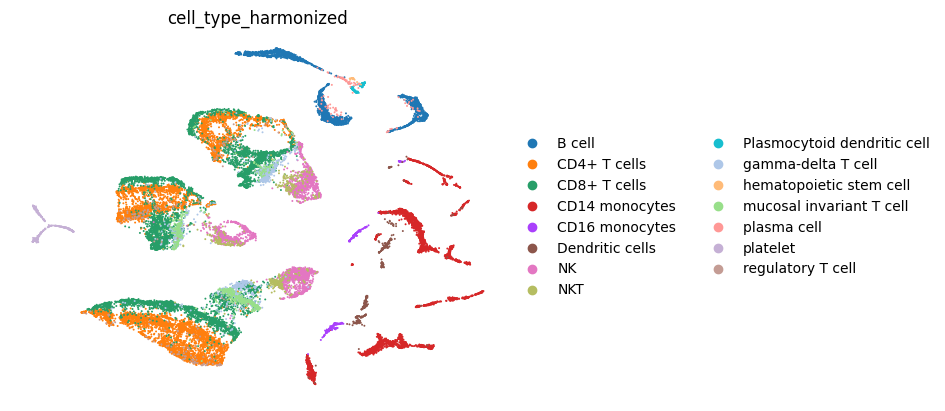

In [27]:
sc.pl.umap(adata_emb, color="cell_type_harmonized", frameon=False, size=8)


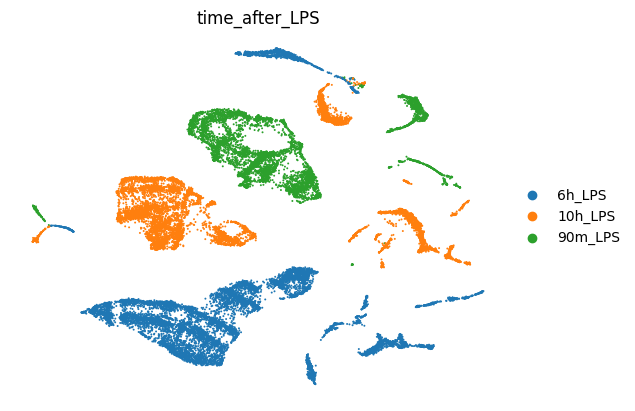

In [28]:
sc.pl.umap(adata_emb, color="time_after_LPS", frameon=False, size=8)


In [ ]:
sc.pl.umap(adata_emb, color="batch", frameon=False, size=8)
sc.pl.umap(adata_emb, color="leiden_emb", frameon=False, size=8)

In [18]:
fig_dir = str(Path(OUTPUT_DIR) / "figures")
os.makedirs(fig_dir, exist_ok=True)

sc.pl.umap(adata_emb, color="cell_type_harmonized", show=False)
plt.savefig(f"{fig_dir}/umap_cell_type.png", dpi=200, bbox_inches="tight")
plt.close()

sc.pl.umap(adata_emb, color="time_after_LPS", show=False)
plt.savefig(f"{fig_dir}/umap_time_after_LPS.png", dpi=200, bbox_inches="tight")
plt.close()

sc.pl.umap(adata_emb, color="batch", show=False)
plt.savefig(f"{fig_dir}/umap_batch.png", dpi=200, bbox_inches="tight")
plt.close()

sc.pl.umap(adata_emb, color="leiden_emb", show=False)
plt.savefig(f"{fig_dir}/umap_leiden_emb.png", dpi=200, bbox_inches="tight")
plt.close()

print("Saved figures under:", fig_dir)

Saved figures under: /mnt/sod2-project/csb4/stuke1/perturbgen/T_perturb/res/masking_split/embeddings_benchmark_test_paper_v1/figures
